## Introduction

One of the primary causes of air pollution in urban areas is transportation and since 2013 road traffic emissions have risen posing increasingly harmful effects to air quality and thus respiratory health (Arif et al., 2025). To begin quantifying the dangerous social and environmental impact of road traffic on the youth, this project aims to investigate if betweenness centrality affects the site location for schools in Kingston, London.

## Methods

Kingston Upon Thames is an surburban town in south-west London, popular for its array of retail stores and proximity to Richmond Park. Kingston is known for its large number of 'Outstanding' Ofsted rated schools (Snobe, 2026) which paired with its commerical appeal and natural attractiveness make it pertinent for locating traffic concentrations. 

Computing betweenness centrality and combining it with the location of school buildings required data from OpenStreetMap, providing a current and comprehensive dataset of street networks and building types used for plotting and constructing informative maps. 

## Analysis and Visualisation

In [1]:
# Importing all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox
import geopandas as gpd
import contextily as ctx
import matplotlib.cm as cm
import matplotlib.colors as colors


In [2]:
# Using osmnx to download network for Kingston Upon Thames, London, at 2000m radius for driving
KT = ox.graph_from_address('Kingston Upon Thames, London', dist=2000, network_type='drive')

# Prints the number of nodes and edges as a check the address/location exists and is correct
print(f"Downloaded street network in Kingston Upon Thames:")
print(f"  Nodes: {KT.number_of_nodes():,}")
print(f"  Edges: {KT.number_of_edges():,}")

Downloaded street network in Kingston Upon Thames:
  Nodes: 1,179
  Edges: 2,663


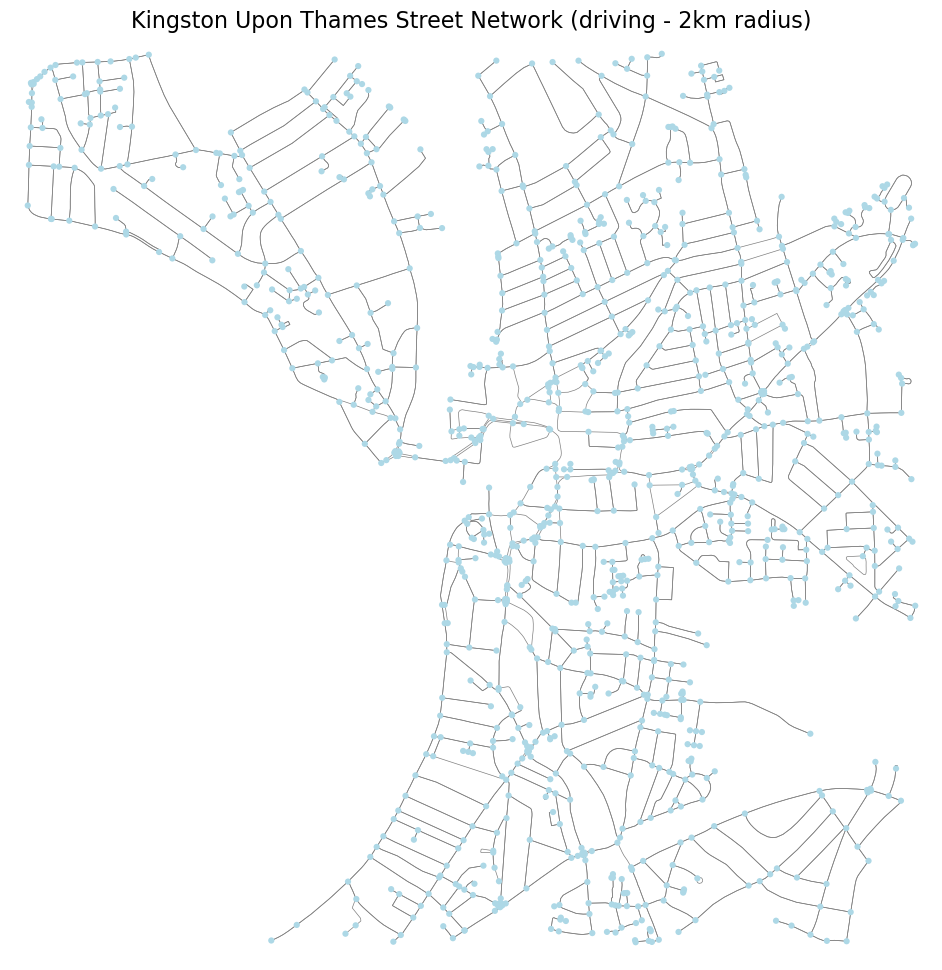

In [3]:
# Plotting the street network (driving) for Kingston to visualise and check correctness before analysis
fig, ax = ox.plot_graph(KT, figsize=(12, 12), 
                        node_color='lightblue', 
                        node_size=20, 
                        edge_color='gray', 
                        edge_linewidth=0.5,
                        bgcolor='white',
                        show=False,
                        close=False)

# Adds a title for the map and then presents it
plt.title("Kingston Upon Thames Street Network (driving - 2km radius)", fontsize=16)
plt.show()

*Figure 1: Raw street network comprised of nodes and edges for driving for Kingston Upon Thames with a 2km radius*

In [4]:
# Convert to DiGraph (directed graph) as some centrality measures require directed graphs
KT_DG = ox.convert.to_digraph(KT)

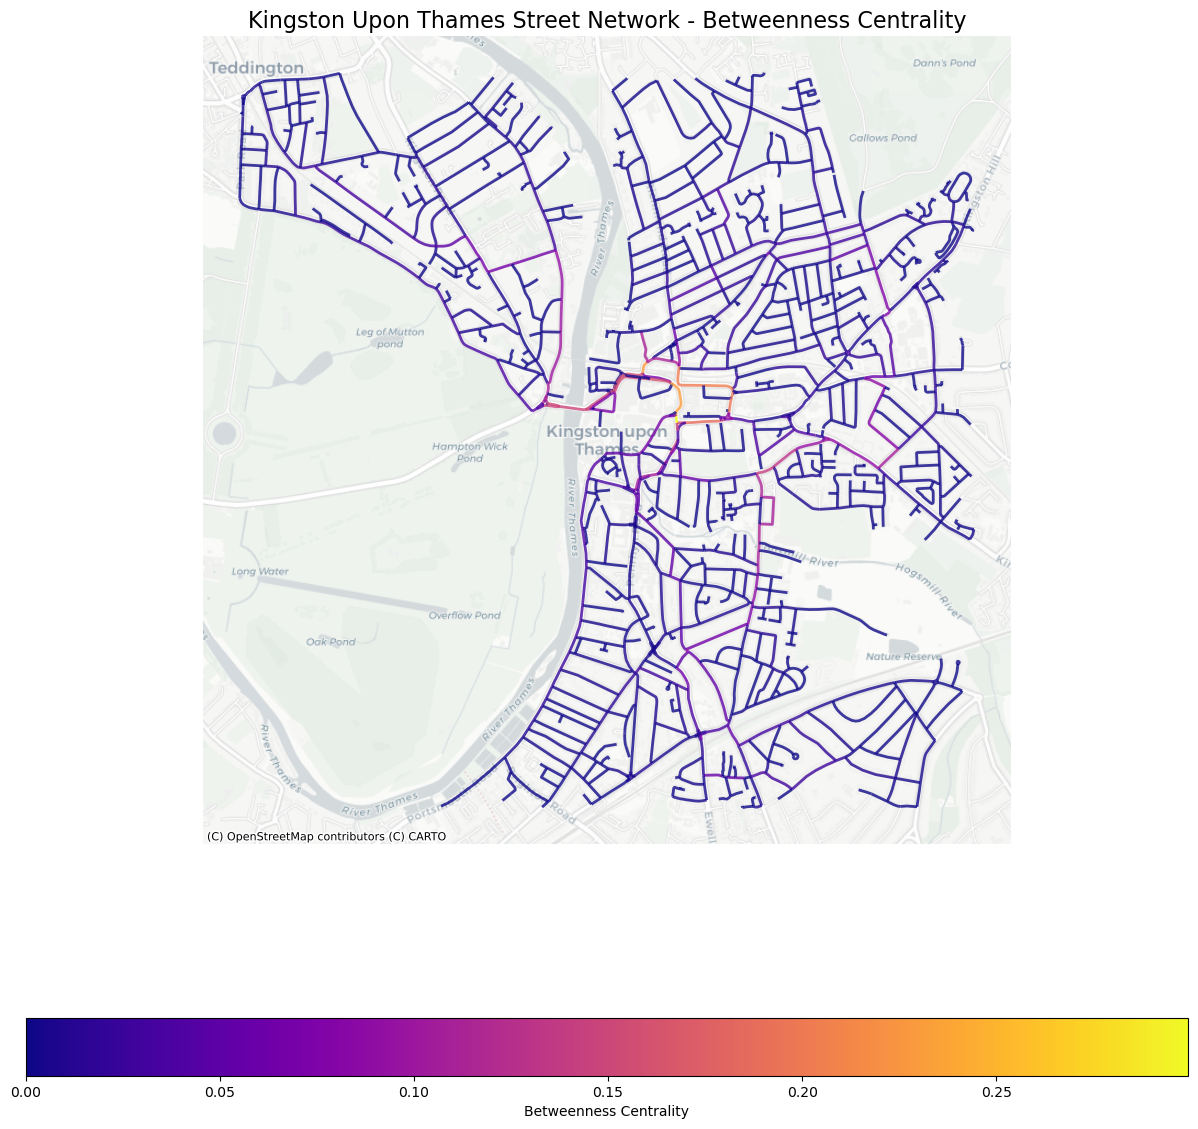

In [5]:
# CALCULATING EDGE BETWEENNESS CENTRALITY FOR KINGSTON 

# Line graph allows each edge to act as a node allowing betweenness to be calculated on 'edges'
edge_bc = nx.betweenness_centrality(nx.line_graph(KT_DG))

# Stores betweenness centrality results back onto original graph as edge attribute 'bc'
nx.set_edge_attributes(KT_DG, edge_bc, 'bc')

# Converts the directed graph to multigraph to be able to handle multiple edges between nodes
KT_multi = nx.MultiGraph(KT_DG)

# Convert the graph into a geodataframe to be plotted using only edges
gdf_edges_bc = ox.graph_to_gdfs(KT_multi, nodes=False, fill_edge_geometry=True)

# Reprojecting the geodataframe into Web Mercator (EPSG:3857) in order to successfully add a basemap and place betweenness centrality in context
gdf_edges_bc = gdf_edges_bc.to_crs(epsg=3857)

#Create the Matplotlib figure for plotting
fig, ax = plt.subplots(figsize=(15, 15))

# Plot the edges as betweenness centrality with a blue-purple-yellow colour scheme and legend showing
gdf_edges_bc.plot(column='bc', 
                  cmap='plasma', 
                  linewidth=2, 
                  alpha=0.8, 
                  ax=ax,
                  legend=True,
                  legend_kwds={'label': 'Betweenness Centrality', 'orientation': 'horizontal'})

# Adds the appropriate light grey, subtle basemap to highlight the betweenness centrality
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Adds the title of the map, removes the axis and presents the map
plt.title("Kingston Upon Thames Street Network - Betweenness Centrality", fontsize=16)
plt.axis('off')
plt.show()

*Figure 2: Betweenness centrality map computed for Kingston Upon Thames with associated legend (blue/purple indicating low traffic with edges rarely being on shortest paths, whilst orange/yellow signifies a highly connective edge and traffic)*

In [6]:
# DOWNLOADING MULTIPLE BUILDING TYPES FOR KINGSTON

# Defining which features we download from OpenStreetMap
tags = {'amenity': True, 'highway': True, 'landuse': True, 
        'building': True, 'waterway': True, 'railway': True}

# Downloads all features within the defined radius for the defined location
all_geom = ox.features_from_address('Kingston Upon Thames, UK', tags, dist=2000)

# Checks that the dataframe for features is not empty
assert len(all_geom) > 0, "No features found — check the address or expand the search radius."

# Transform to Web Mercator (EPSG:3857) in order to add basemap
all_geom = all_geom.to_crs(epsg=3857)

# Checking the right data has been downloaded by printing the number of features produced for this location
print(f"Downloaded {len(all_geom)} features")


Downloaded 17287 features


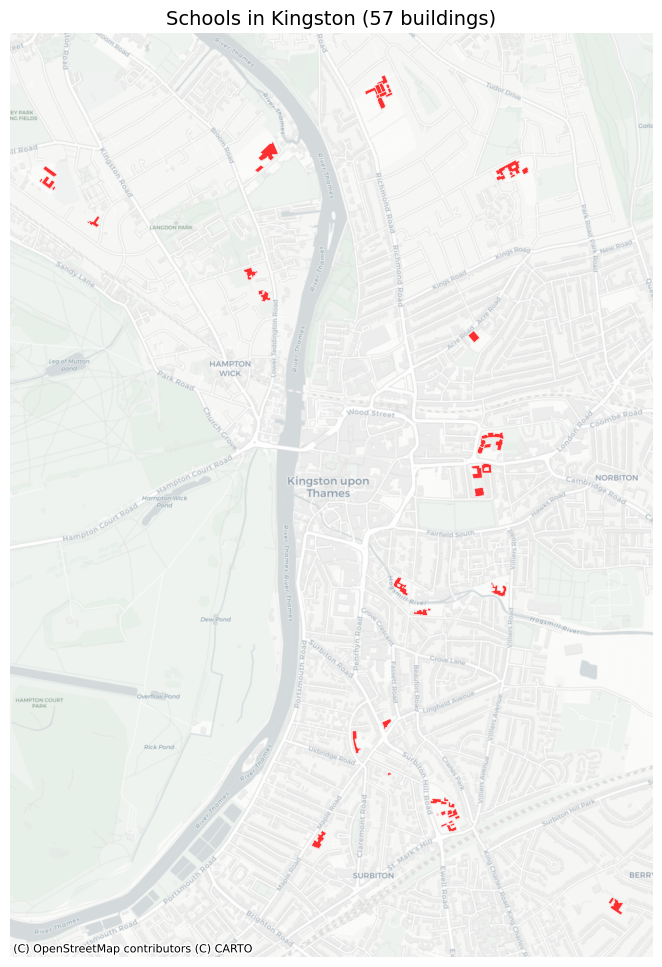

In [7]:
# FILTERING FOR SCHOOL BUILDINGS IN KINGSTON 

# Creates matplotlib figure and axis for the map
fig, ax = plt.subplots(figsize=(12, 12))

# Filter the data to only meet the criteria of 'building' AND 'school'
school_buildings = all_geom[
    all_geom['building'].notna() & 
    all_geom['building'].str.contains('school', case=False, na=False)
]

# Checks that there exists at least one school building, otherwise error message
assert len(school_buildings) > 0, "No school buildings found — check spelling or OSM coverage."

# Plotting the filtered school buildings in red to stand out amongst basemap and later betweenness centrality colours
school_buildings.plot(ax=ax, color='red', alpha=0.8, edgecolor='white', linewidth=0.5)

# Adds the basemap for spatial context and highlighting school buildings
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Adds map title with number of school buildings, removes axis, and presents map
plt.title(f"Schools in Kingston ({len(school_buildings)} buildings)", fontsize=14)
plt.axis('off')
plt.show()

*Figure 3: Map of schools (highlighted red) in Kingston Upon Thames*

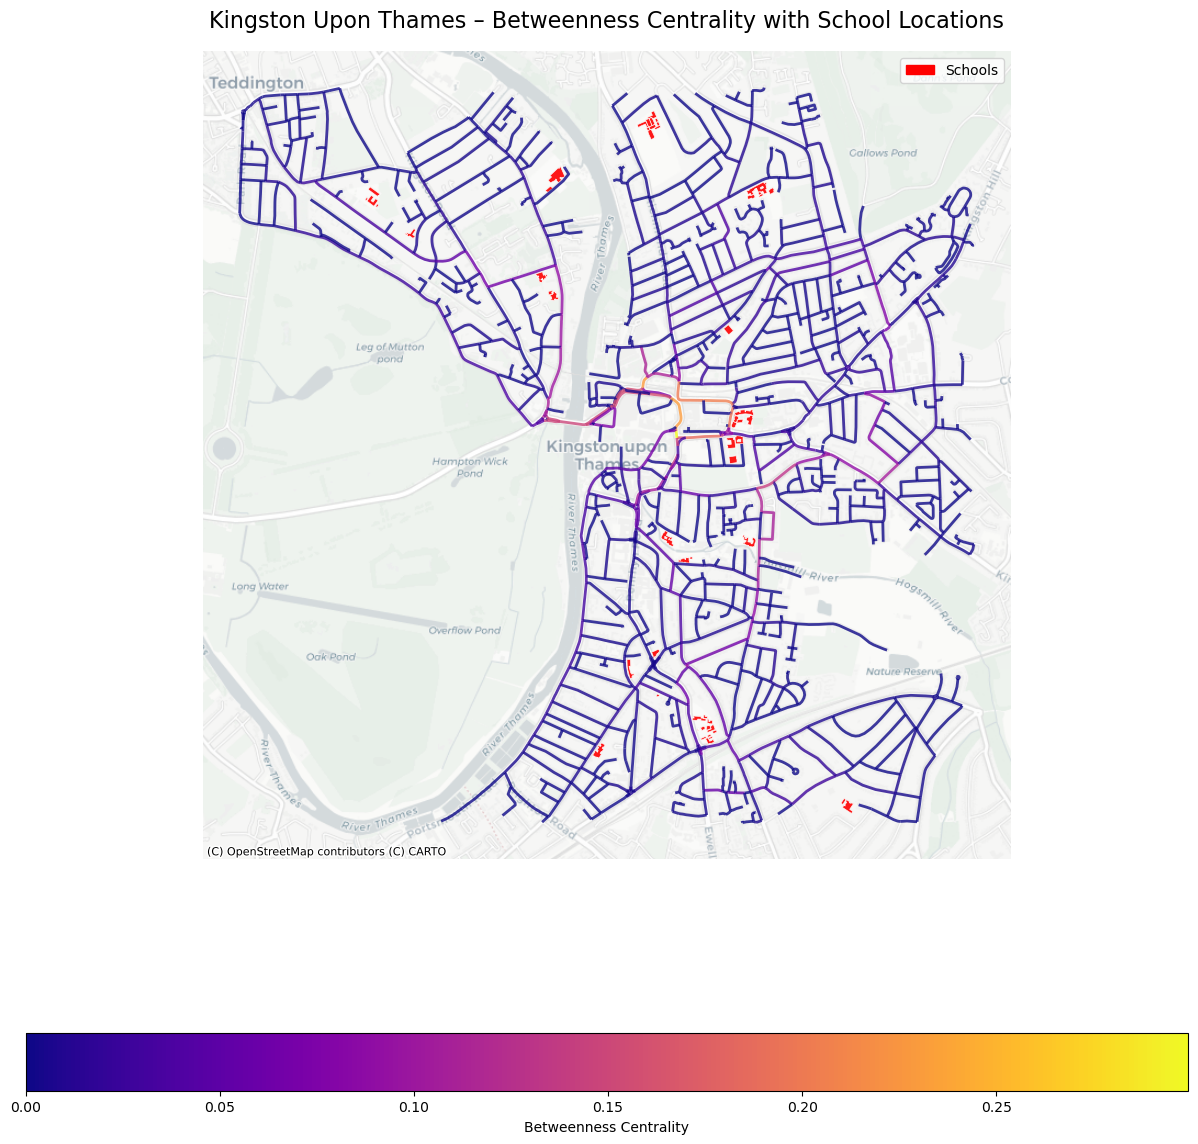

In [8]:
# COMBINING BETWEENNESS CENTRALITY AND SCHOOL BUILDING LOCATIONS FOR KINGSTON

# Quick check to show that the betweenness centrality data/graph exists
assert KT_DG.number_of_edges() > 0, "The graph has no edges — centrality cannot be computed."

# Line graph allows each edge to act as a node allowing betweenness to be calculated on 'edges'
edge_bc = nx.betweenness_centrality(nx.line_graph(KT_DG))

# Stores betweenness centrality results back onto original graph as edge attribute 'bc'
nx.set_edge_attributes(KT_DG, edge_bc, 'bc')

# Converts the directed graph to multigraph to be able to handle multiple edges between nodes
KT_multi = nx.MultiGraph(KT_DG)

# Convert the graph into a geodataframe to be plotted using only edges
gdf_edges_bc = ox.graph_to_gdfs(KT_multi, nodes=False, fill_edge_geometry=True)

# Reprojecting the geodataframe into Web Mercator (EPSG:3857) in order to successfully add a basemap and place betweenness centrality in context
gdf_edges_bc = gdf_edges_bc.to_crs(epsg=3857)

# Filter the data to only meet the criteria of 'building' AND 'school'
school_buildings = all_geom[
    all_geom['building'].notna() &
    all_geom['building'].str.contains('school', case=False, na=False)
]

# Reproject schools to the same CRS as the basemap
school_buildings = school_buildings.to_crs(epsg=3857)

# Creates a matplotlib figure and axis to combine the plots
fig, ax = plt.subplots(figsize=(15, 15))

# Plot the edges as betweenness centrality with a blue-purple-yellow colour scheme and legend showing
gdf_edges_bc.plot(
    column='bc',
    cmap='plasma',
    linewidth=2,
    alpha=0.8,
    ax=ax,
    legend=True,
    legend_kwds={'label': 'Betweenness Centrality', 'orientation': 'horizontal'}
)

# Plot the school buildings on top of the betweenness centrality map, with red colours to stand out and differentiate
school_buildings.plot(
    ax=ax,
    color='red',
    alpha=0.9,
    edgecolor='white',
    linewidth=0.5,
    markersize=40,
    label='Schools'
)

# Adds a subtle basemap for spatial context and highlight data on top
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Adds a title for the map
plt.title("Kingston Upon Thames – Betweenness Centrality with School Locations", fontsize=16)

# Importing library to manually add own legend for school buildings in the upper-right appropriately coloured red
import matplotlib.patches as mpatches 
school_patch = mpatches.Patch(color='red', label='Schools') 
ax.legend(handles=[school_patch], loc='upper right')

# The map axis are turned off and the map is presented
plt.axis('off')
plt.show()


*Figure 4: Map of both betweenness centrality and location of schools in Kingston Upon Thames with associated legend*

## Discussion

Figures 1/2/3 provide context concerning the connectivity of street networks in Kingston and highlight the spatial distribution of schools. Figure 4 intends to compare road traffic with proximity to schools and the results show despite the majority of schools being roughly evenly distributed among the peripheral streets of the network with low betweenness centrality, a few schools are adjacent to moderate traffic levels, and two schools (KGS and Tiffin) are found within high betweenness centrality streets. This suggests whilst the majority of schools are evenly distributed in low traffic zones, a select few in high traffic areas particularly toward the centre of town are more likely to have adverse safety and health implications for their students. This map is limited by many schools being omitted potentially deeming the OpenStreetMap data unreliable, however, a site for potential traffic reduction can be noted as Queen Elizabeth Road.

## References

Arif, I., Jaweria, A., Munir, F. (2025). Health Impacts of Road Traffic near School - a Narrative Review. Pakistan Armed Forces Medical Journal, 75, 209-216

Snobe. (2026). Find All Schools in Kingston Upon Thames - 61 Schools. 2026 Snobe. Available at: https://snobe.co.uk/best-schools/kingston-upon-thames. [Accessed 6th February 2026]